### 10x file preprocessing

This notebook was used to create the 10x dataset used in tutorial 03_training_prediciton. Initial files can be downloaded from the 10x website (https://www.10xgenomics.com/resources/datasets under and the keywords "a new way immune profiling"). It is also an updated form of a notebook from our reproducibility repository of which the resulting dataset was used for the publication (https://github.com/SchubertLab/mvTCR_reproducibility/blob/master/preprocessing/10x_preprocessing.ipynb)

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os 
import numpy as np
import scipy as sci
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as pl

import scanpy as sc
import scirpy as ir
import anndata as ann
import awkward as ak

from scipy.sparse import csr_matrix
from matplotlib import rcParams
from matplotlib import colors

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
path_base = ''
path_merged = path_base + 'merged_tcr_10x.h5ad'
path_filtered = path_base + 'filtered_tcr_10x.h5ad'
path_logged = path_base + 'logged_10x.h5ad'
path_highlyvar = path_base + 'highly_var_5000.h5ad'
path_clean_split = path_base + 'v5_train_val_test.h5ad'
path_supervised = path_base + 'v6_supervised.h5ad'
path_avidity = path_base + 'v7_avidity.h5ad'

In [37]:
import muon as mu
# mdata = mu.read("/ihome/ylee/yiz133/Code/Data processing/all_Common_DEtop2500.h5mu")

mdata = mu.read("/ix1/ylee/Yifan_Zhang/Code_data/data_EAE/anndata/all_Common.h5mu")    # work

adata = mdata['gex']
adata.obsm['airr'] = mdata.mod['airr'].obsm['airr']

In [38]:
adata.obs['mouse_id'].value_counts()

mouse_id
6_3    13686
6_4    12080
6_2    11550
6_1     9370
5_3     6304
5_4     6153
5_7     5216
5_5     4752
5_6     4324
5_8     4225
Name: count, dtype: int64

In [39]:
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log10(adata.obs['n_counts'])

adata.obs['n_genes'] = (adata.X > 0).sum(1)

mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
mt_gene_index = np.where(mt_gene_mask)[0]
adata.obs['mt_fraction'] = adata.X[:, mt_gene_index].sum(1) / adata.X.sum(1)

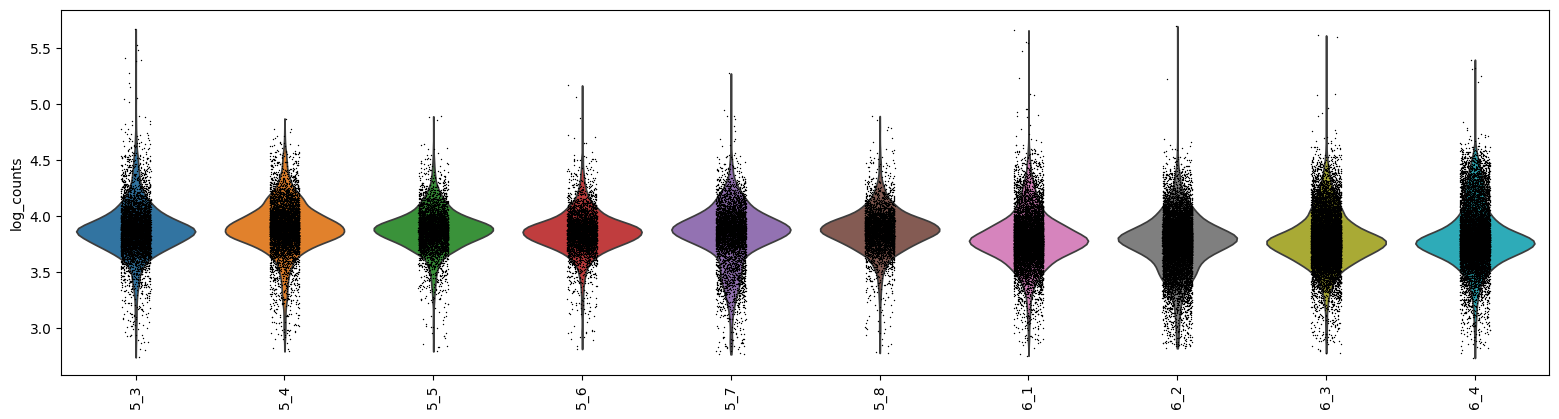

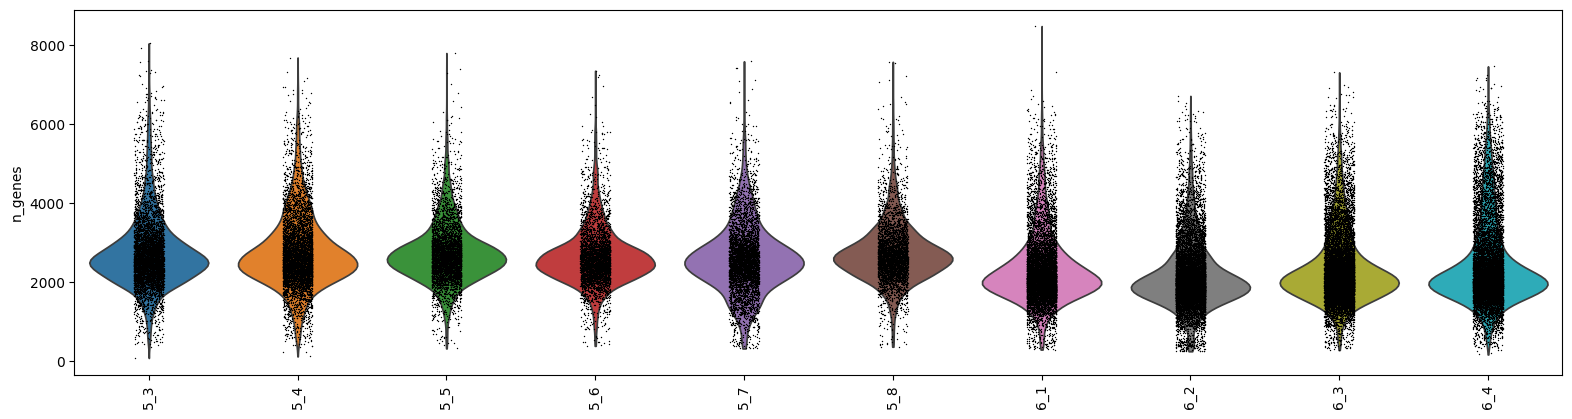

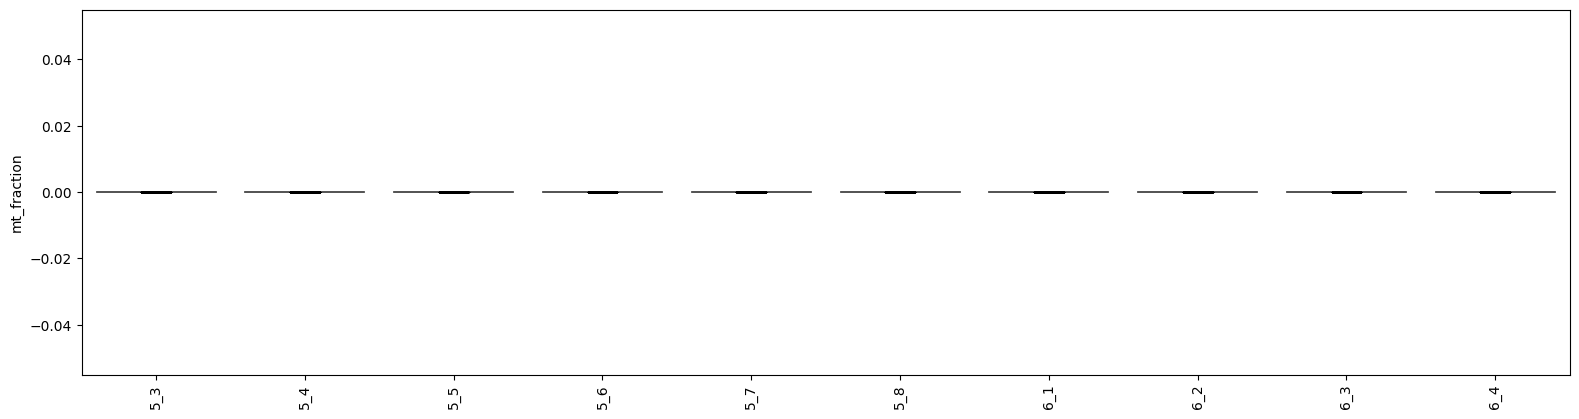

In [40]:
rcParams['figure.figsize'] = (15, 5)
sc.pl.violin(adata, ['log_counts'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata, ['n_genes'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata, ['mt_fraction'], groupby='mouse_id', size=1, log=False, rotation=90)

<Axes: title={'center': 'mt fraction'}, xlabel='n_counts', ylabel='n_genes'>

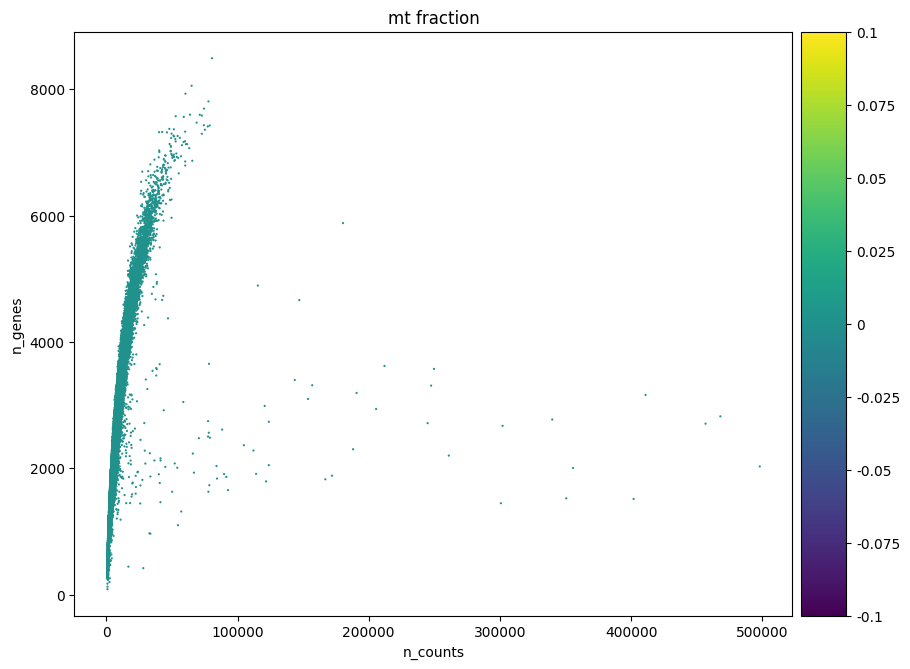

In [41]:
rcParams['figure.figsize'] = (8, 8)
sc.pl.scatter(adata, y='n_genes', x='n_counts', color='mt_fraction', size=10, show=False)

<Axes: title={'center': 'mouse id'}, xlabel='n_counts', ylabel='n_genes'>

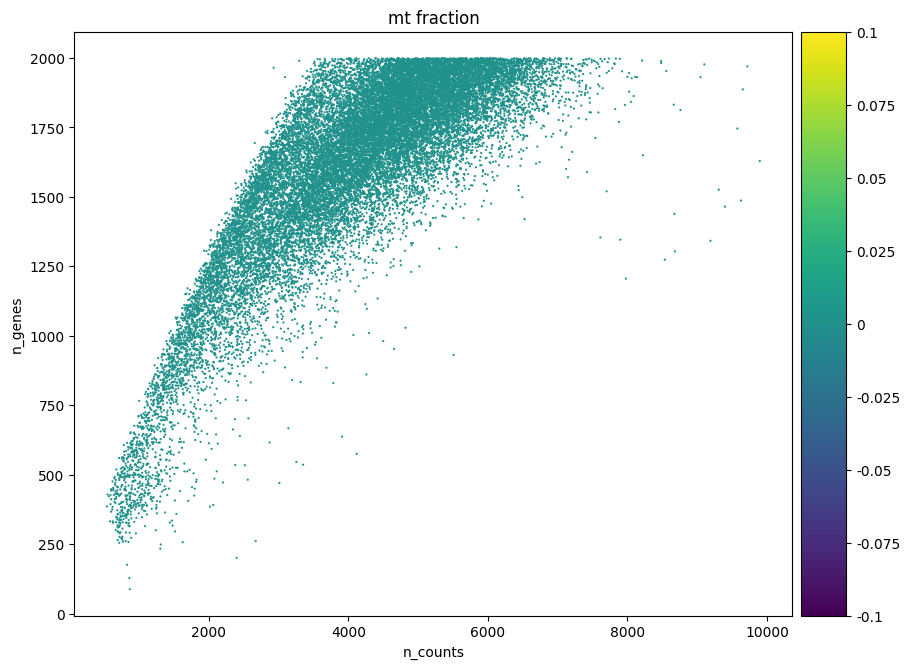

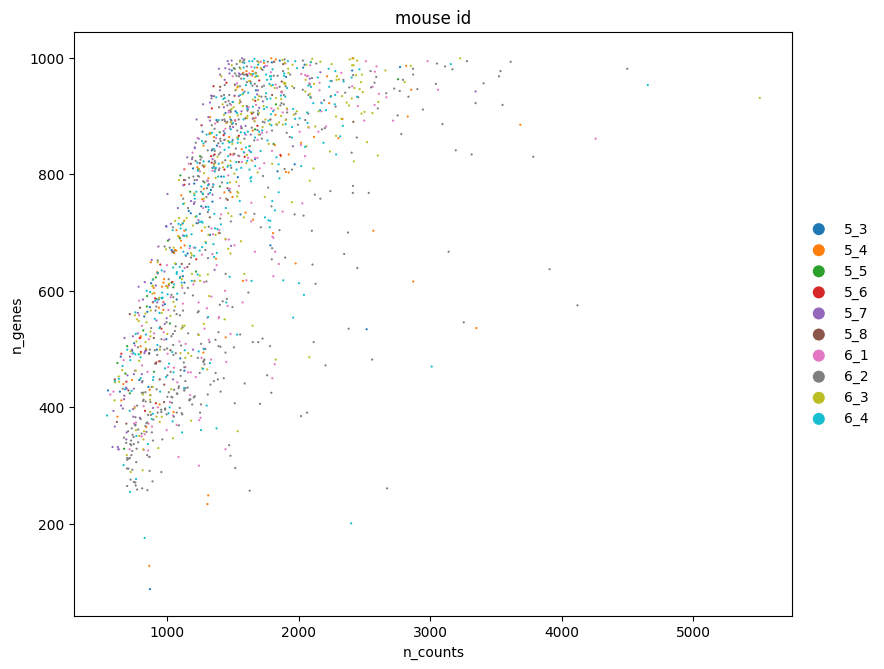

In [42]:
sc.pl.scatter(adata[np.logical_and(adata.obs['n_genes']<2000, adata.obs['n_counts']<10000)],
             y='n_genes', x='n_counts', color='mt_fraction', size=10, show=False)
sc.pl.scatter(adata[np.logical_and(adata.obs['n_genes']<1000, adata.obs['n_counts']<10000)],
             y='n_genes', x='n_counts', color='mouse_id', size=10, show=False)

In [43]:
adata_tmp = adata.copy()
print(f'Total number of cells: {adata_tmp.n_obs}')
high_mt = adata_tmp.obs['mt_fraction'] < 0.2  #todo why this value
adata_tmp = adata_tmp[high_mt]
print(f'Number of cells after MT filter: {adata_tmp.n_obs}')

Total number of cells: 77660
Number of cells after MT filter: 77660


In [44]:
low_count = adata_tmp.obs['n_counts'] > 1000
adata_tmp = adata_tmp[low_count]
print(f'Number of cells after minimum count filter: {adata_tmp.n_obs}')

sc.pp.filter_cells(adata_tmp, max_counts=10000)
print(f'Number of cells after maximum filter: {adata_tmp.n_obs}')

Number of cells after minimum count filter: 77326


/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


Number of cells after maximum filter: 63210


In [45]:
low_genes = adata_tmp.obs['n_genes'] > 500
adata_tmp = adata_tmp[low_genes]
print(f'Number of cells after minimum gene filter: {adata_tmp.n_obs}')

Number of cells after minimum gene filter: 63083


In [46]:
sc.pp.filter_genes(adata_tmp, min_cells=10)
print(f'Number of cells after gene filter: {adata_tmp.n_vars}')

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


Number of cells after gene filter: 19198


In [47]:
import scrublet as scr
import scipy.io
import time

In [48]:
adata_tmp.obs['doublet_score'] = np.zeros(adata_tmp.shape[0])
adata_tmp.obs['doublet'] = np.zeros(adata_tmp.shape[0])

In [49]:
# filtering / preprocessing parameters:
min_counts = 2
min_cells = 3
vscore_percentile = 85
n_pc = 50

# doublet detector parameters
expected_doublet_rate = 0.02
sim_doublet_ratio = 3
n_neighbors = 15

for batch in enumerate(adata_tmp.obs['mouse_id'].cat.categories):
    print(batch)
    t0 = time.time()
    idx = np.flatnonzero(adata_tmp.obs['mouse_id']==batch[1])
    scrub = scr.Scrublet(counts_matrix = adata_tmp[idx, :].X,
                        n_neighbors = n_neighbors,
                        sim_doublet_ratio = sim_doublet_ratio,
                        expected_doublet_rate = expected_doublet_rate)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts = min_counts,
                                                              min_cells = min_cells,
                                                              n_prin_comps = n_pc,
                                                              use_approx_neighbors = True,
                                                              get_doublet_neighbor_parents = False)
    adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores
    adata_tmp.obs['doublet'].iloc[idx] = predicted_doublets
    t1 = time.time()
    print('Elapsed time: {:.1f} seconds'.format(t1-t0))

(0, '5_3')
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.14
Detected doublet rate = 0.9%
Estimated detectable doublet fraction = 31.1%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 3.0%
Elapsed time: 6.6 seconds
Elapsed time: 6.7 seconds
(1, '5_4')
Preprocessing...


/scratch/slurm-6231739/ipykernel_1427327/3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores
/scratch/slurm-6231739/ipykernel_1427327/3502024312.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet'].iloc[idx] = predicted_doublets


Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.14
Detected doublet rate = 1.5%
Estimated detectable doublet fraction = 26.2%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 5.8%
Elapsed time: 6.1 seconds
Elapsed time: 6.3 seconds
(2, '5_5')
Preprocessing...


/scratch/slurm-6231739/ipykernel_1427327/3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores


Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.14
Detected doublet rate = 1.3%
Estimated detectable doublet fraction = 35.2%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 3.7%
Elapsed time: 4.9 seconds
Elapsed time: 5.0 seconds
(3, '5_6')
Preprocessing...


...

/scratch/slurm-6231739/ipykernel_1427327/3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.14
Detected doublet rate = 0.8%
Estimated detectable doublet fraction = 39.3%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 2.1%
Elapsed time: 17.0 seconds
Elapsed time: 17.5 seconds
(9, '6_4')


/scratch/slurm-6231739/ipykernel_1427327/3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.14
Detected doublet rate = 1.2%
Estimated detectable doublet fraction = 38.9%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 3.2%
Elapsed time: 14.0 seconds
Elapsed time: 14.3 seconds


/scratch/slurm-6231739/ipykernel_1427327/3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores


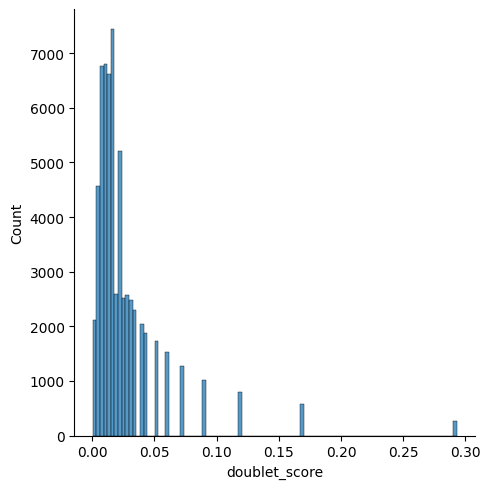

In [50]:
rcParams['figure.figsize'] = (6, 6)
sb.displot(adata_tmp.obs['doublet_score'], bins=100, kde=False)

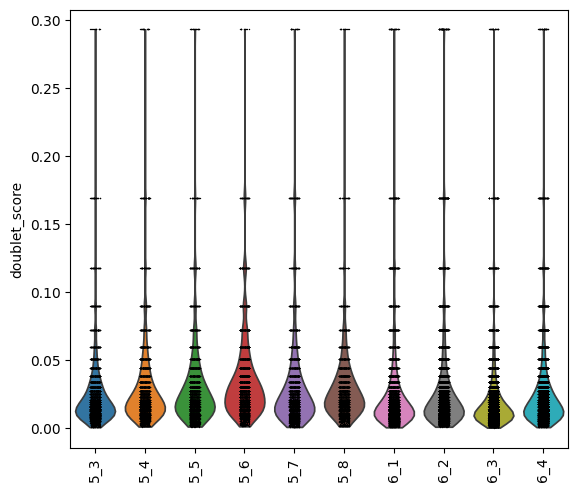

In [51]:
sc.pl.violin(adata_tmp, ['doublet_score'], groupby='mouse_id', size=1, log=False, rotation=90)

In [52]:
thr = 0.05
idx_filter = adata_tmp.obs['doublet_score'] <= thr

adata_tmp = adata_tmp[idx_filter].copy()
print(f'Number of cells after double filter: {adata_tmp.n_obs}')

Number of cells after double filter: 55892


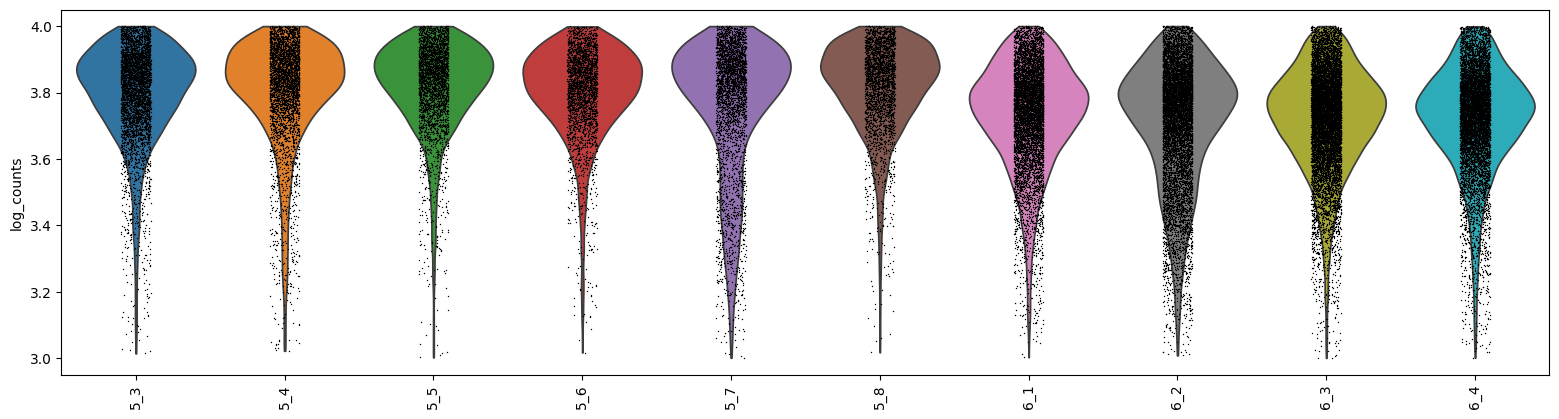

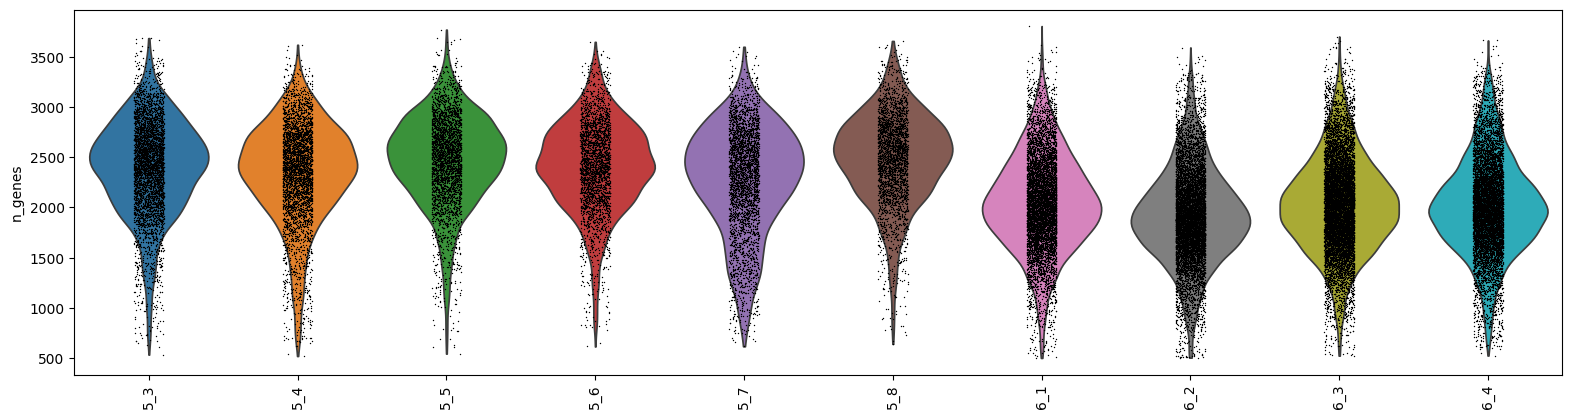

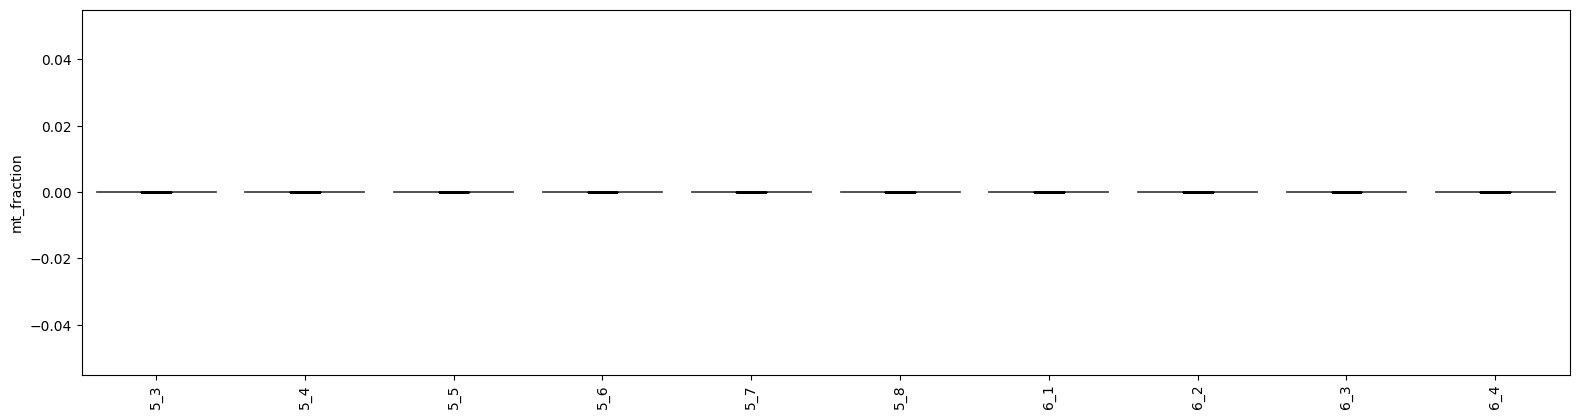

In [53]:
rcParams['figure.figsize'] = (15, 5)
sc.pl.violin(adata_tmp, ['log_counts'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata_tmp, ['n_genes'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata_tmp, ['mt_fraction'], groupby='mouse_id', size=1, log=False, rotation=90)

In [54]:
df = adata_tmp.obs[['n_genes', 'n_counts', 'mouse_id']]
df_all = pd.DataFrame(df.groupby(by='mouse_id')['n_genes'].apply(np.mean).values, 
                      index=df.groupby(by='mouse_id')['n_genes'].apply(np.mean).index, 
                      columns=['mean_genes'])

df_all['median_genes'] = df.groupby(by='mouse_id')['n_genes'].apply(np.median).values
df_all['mean_counts'] = df.groupby(by='mouse_id')['n_counts'].apply(np.mean).values
df_all['median_counts'] = df.groupby(by='mouse_id')['n_counts'].apply(np.median).values
df_all

,mean_genes,median_genes,mean_counts,median_counts
mouse_id,,,,
5_3,2396.083408,2440.5,6561.633789,6706.0
5_4,2340.439969,2394.0,6688.490723,6878.0
5_5,2467.241115,2508.5,6822.346191,6983.0
5_6,2408.903660,2430.0,6578.265137,6653.0
5_7,2271.497967,2350.5,6220.303223,6589.5
5_8,2483.721429,2523.0,6817.164062,6953.0
6_1,2046.429891,2029.0,5700.768066,5668.5
6_2,1917.255407,1898.0,5495.153320,5587.5
6_3,2026.910322,2013.0,5551.201660,5478.5


In [55]:
adata_tmp.obs['doublet'] = adata_tmp.obs['doublet'].astype(str)

In [56]:
sc.write(adata=adata_tmp, filename=path_filtered)

In [57]:
sc.pp.normalize_total(adata_tmp, target_sum=1e4)
sc.pp.log1p(adata_tmp)

In [58]:
sc.write(adata=adata_tmp, filename=path_logged)

In [59]:
adata_tmp.uns['log1p'] = {'base': None}
sc.pp.highly_variable_genes(adata_tmp, n_top_genes=5000, batch_key='mouse_id')
print('Shape before: ', adata_tmp.shape)
adata = adata_tmp[:, adata_tmp.var['highly_variable']]
print('Shape after:  ', adata.shape)

Shape before:  (55892, 19198)
Shape after:   (55892, 5000)


In [60]:
sc.write(adata=adata, filename=path_highlyvar)

In [61]:
junction_aa = ir.get.airr(adata, "junction_aa")
cells_with_both_chains = ~(junction_aa['VJ_1_junction_aa'].isna() | junction_aa['VDJ_1_junction_aa'].isna())
print(adata.shape)
adata = adata[cells_with_both_chains]
print(adata.shape)

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/scirpy/pp/_index_chains.py:142: ImplicitModificationWarning: Setting element `.obsm['chain_indices']` of view, initializing view as actual.
  params.adata.obsm[key_added] = ak.zip(res, depth_limit=1)  # type: ignore


(55892, 5000)
(51403, 5000)


In [62]:
from mvtcr.utils_preprocessing import Preprocessing

In [63]:
Preprocessing.check_if_valid_adata(adata)

True

In [64]:
Preprocessing.encode_clonotypes(adata)

In [65]:
Preprocessing.encode_tcr(adata, airr_name='junction_aa', 
               alpha_label_key='alpha_seq', alpha_length_key='alpha_len',
               beta_label_key='beta_seq', beta_length_key='beta_len')

In [66]:
antigen_binding_list = [x for x in adata.obs.columns if x.endswith('_binder')]
len(antigen_binding_list)

0

In [67]:
binding_matrix = (adata.obs[antigen_binding_list] == 'True').values.astype(int)
binding_matrix.shape

(51403, 0)

In [68]:
unique_value, count = np.unique(binding_matrix.sum(axis=1), return_counts=True)
for unique_value_, count_ in zip(unique_value, count):
    print(f'Cells with {unique_value_} bindings: {count_}')

Cells with 0 bindings: 51403


In [69]:
label_to_binding = {label_id: antigen for label_id, antigen in enumerate(antigen_binding_list)}
label_to_binding[-1] = 'no_data'  # For cells without binding data
binding_to_label = {antigen: label_id for label_id, antigen in enumerate(antigen_binding_list)}
binding_to_label['no_data'] = -1
binding_to_label == {v: k for k, v in label_to_binding.items()}  # sanity check, if both dicts are the reverse of each other

True

In [70]:
adata.obs['has_binding'] = binding_matrix.sum(axis=1).astype(bool)
adata.obs['has_binding'].head()

AAACCAAAGGGGAGCT-1_0516_CNS    False
AAACCAGCACGTAAAG-1_0516_CNS    False
AAACCATTCCTCCGGT-1_0516_CNS    False
AAACCCATCAGTATCG-1_0516_CNS    False
AAACCCCAGCCTAAGC-1_0516_CNS    False
Name: has_binding, dtype: bool

In [75]:
random_seed = 15
# Create Train-Val and Test set
train_val, test = Preprocessing.stratified_group_shuffle_split(adata, stratify_col='mouse_id', group_col='clonotype', test_size=0.2, random_seed=random_seed)
# Split Train-Val into Train and Val set
train, val = Preprocessing.stratified_group_shuffle_split(adata[train_val], stratify_col='mouse_id', group_col='clonotype', test_size=0.25, random_seed=random_seed)

100%|██████████| 10/10 [00:00<00:00, 107.20it/s]


In [76]:
print('Train Samples: ', len(train))
print('Train Ratio: ', len(train) / len(adata.obs))
print('Val Samples: ', len(val))
print('Val Ratio: ', len(val) / len(adata.obs))
print('Test Samples: ', len(test))
print('Test Ratio: ', len(test) / len(adata.obs))

Train Samples:  30966
Train Ratio:  0.602416201389024
Val Samples:  10241
Val Ratio:  0.19922961694842714
Test Samples:  10196
Test Ratio:  0.19835418166254887


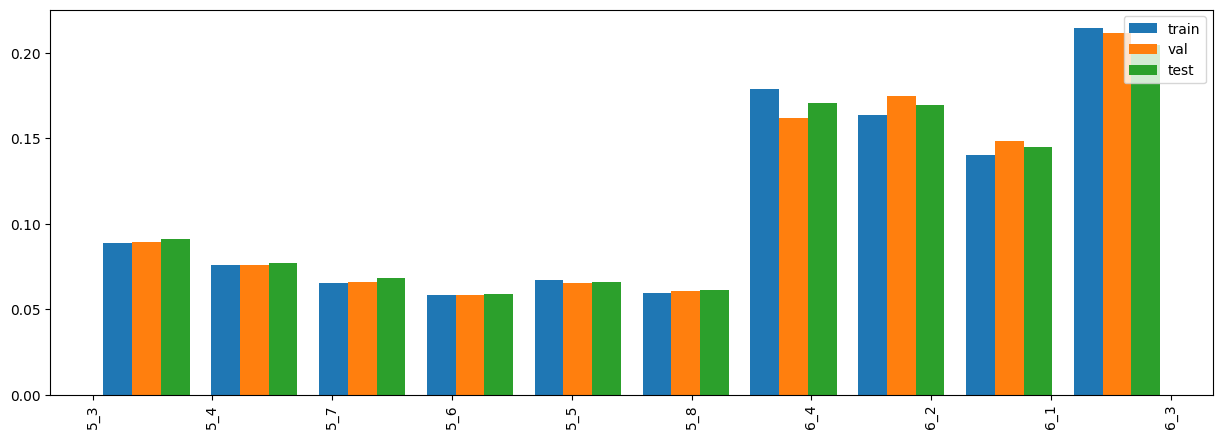

In [77]:
pl.figure(figsize=(15,5))
pl.hist([adata.obs.loc[train]["mouse_id"], adata.obs.loc[val]["mouse_id"], adata.obs.loc[test]["mouse_id"]], density=True, bins=len(adata.obs.loc[train]["mouse_id"].unique()), label=['train', 'val', 'test'])
pl.xticks(rotation='vertical')
pl.legend(loc='upper right')
pl.show()

In [78]:
form_train = set(adata.obs.loc[train]['clonotype'].tolist())
form_val = set(adata.obs.loc[val]['clonotype'].tolist())
form_test = set(adata.obs.loc[test]['clonotype'].tolist())

print('Intersection in clonotypes between two sets should be empty\n')
print('Intersection in clonotypes between train and test: ', form_train.intersection(form_test))
print('Intersection in clonotypes between train and val: ', form_train.intersection(form_val))
print('Intersection in clonotypes between val and test: ', form_val.intersection(form_test))
# print('\nSanity Check - Intersection in clonotypes between train and train: ', form_train.intersection(form_train))

Intersection in clonotypes between two sets should be empty

Intersection in clonotypes between train and test:  set()
Intersection in clonotypes between train and val:  set()
Intersection in clonotypes between val and test:  set()


In [79]:
adata.obs.loc[train, 'set'] = 'train'
adata.obs.loc[val, 'set'] = 'val'
adata.obs.loc[test, 'set'] = 'test'
adata.obs['set'].value_counts()

set
train    30966
val      10241
test     10196
Name: count, dtype: int64

In [80]:
adata.obs['set'].sample(20)

GGGCTAAAGCGCTTGG-1_0516_SPL      val
AAACCTGTCCGATGGT-1_0516_SPL    train
ATTCGTACAACTGCAT-1_0605_CNS     test
GTACTTACAGGTTCGC-1_0516_CNS    train
CAGTAGGAGCGACAGA-1_0605_CNS    train
GTATCCCGTCCTCGAT-1_0605_CNS    train
AAGCTAAAGGGAGATT-1_0605_SPL      val
ACCCCTGGTATCAGGT-1_0605_SPL     test
ACAGGTCTCGTTGTCT-1_0516_SPL    train
AACACCCAGGTAAATG-1_0516_SPL     test
GTCTATTGTAGTATGC-1_0605_CNS    train
CAGTCCCTCATCAGCA-1_0605_SPL     test
ACATCTCTCGGAAACG-1_0605_SPL    train
CCATAATAGCCATTTC-1_0605_CNS    train
AGTTAGAAGGGTTCCG-1_0516_SPL      val
GTGTCAGGTATAAGGG-1_0516_SPL    train
ATATGAGAGGTGAGAT-1_0516_SPL      val
AACCGCAGTCCAGTAG-1_0605_SPL     test
GCATAGTGTAATCGCG-1_0605_SPL    train
GCTAGATGTCTTATGT-1_0516_SPL    train
Name: set, dtype: object

In [81]:
adata.write_h5ad(path_clean_split, compression='gzip')

In [82]:
Preprocessing.check_if_valid_adata(adata)

True

In [83]:
import config.constants_10x as constants
high_count_antigens = constants.HIGH_COUNT_ANTIGENS.copy()
high_count_antigens

['A0201_ELAGIGILTV_MART-1_Cancer_binder',
 'A0201_GILGFVFTL_Flu-MP_Influenza_binder',
 'A0201_GLCTLVAML_BMLF1_EBV_binder',
 'A0301_KLGGALQAK_IE-1_CMV_binder',
 'A0301_RLRAEAQVK_EMNA-3A_EBV_binder',
 'A1101_IVTDFSVIK_EBNA-3B_EBV_binder',
 'A1101_AVFDRKSDAK_EBNA-3B_EBV_binder',
 'B0801_RAKFKQLL_BZLF1_EBV_binder']

In [84]:
sc.write(adata=adata, filename=path_supervised)

In [85]:
Preprocessing.check_if_valid_adata(adata)

True

In [86]:
sc.write(adata=adata, filename=path_avidity)

In [88]:
adata

AnnData object with n_obs × n_vars = 51403 × 5000
    obs: 'mouse_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_counts', 'log_counts', 'n_genes', 'mt_fraction', 'doublet_score', 'doublet', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len', 'has_binding', 'set'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'mouse_id_colors', 'log1p', 'hvg', 'chain_indices', 'ir_dist_nt_identity', 'clonotype', 'aa_to_id'
    obsm: 'airr', 'chain_indices', 'alpha_seq', 'beta_seq'